C:\Users\karlw\AppData\Local\Temp\ipykernel_33036\1797537715.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["has_med"] = med_text.str.contains(med_query, na=False)
C:\Users\karlw\AppData\Local\Temp\ipykernel_33036\1797537715.py:79: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["any_med"] = med_text.str.contains(r"\w", na=False)
C:\Users\karlw\AppData\Local\Temp\ipykernel_33036\1797537715.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

Rows: 24497
Medication prevalence: 0.19573825366371392
Med group: 4795
Ctrl group: 19702


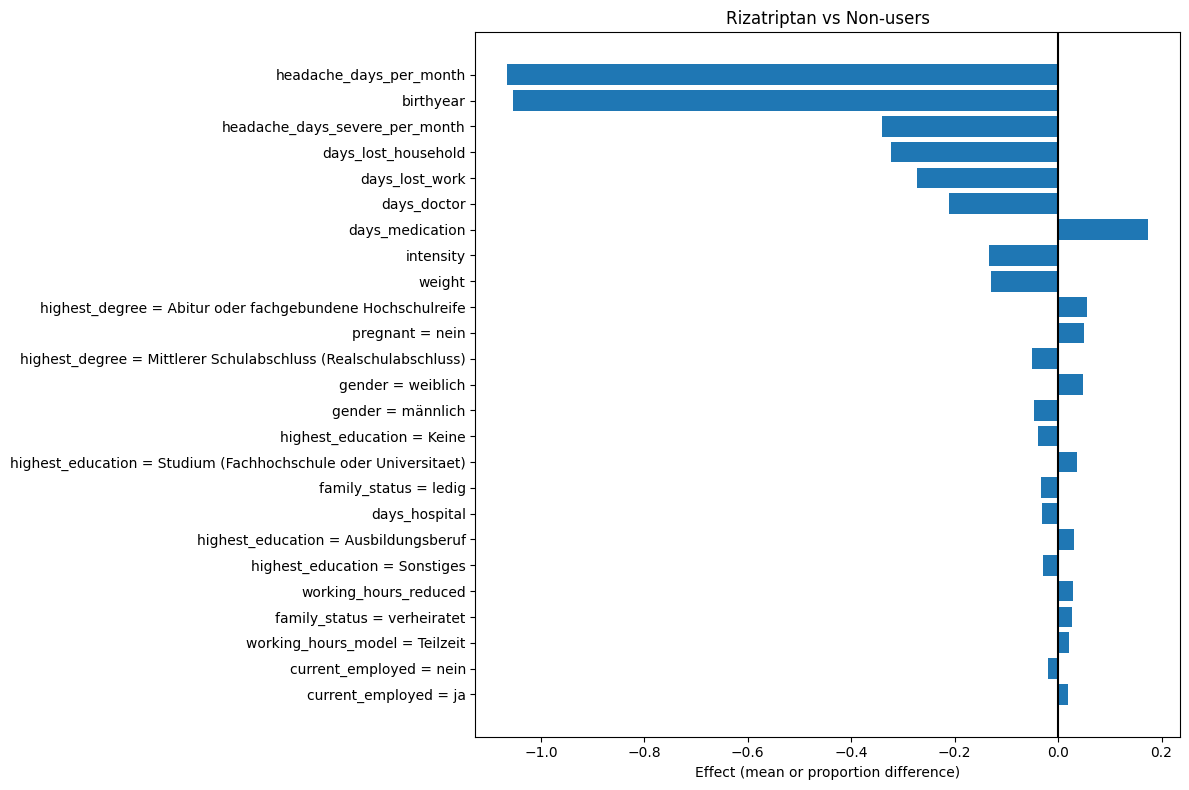

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re
import textwrap

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

MEDICATION_QUERY = "Rizatriptan"

factor_prefixes = [
    "gender","birthyear","weight","pregnant",
    "highest_degree","highest_education","family_status",
    "current_employed","working_hours_model","shiftwork",
    "working_hours_reduced","promotion_waived","children",
    "headache_days_per_month","headache_days_severe_per_month",
    "days_medication","intensity","days_lost_work",
    "days_lost_household","days_doctor","days_ER","days_hospital"
]

# =========================================================
# SAFE K-COLLAPSE
# =========================================================

def collapse_k_columns(df, prefixes):

    out = {}

    for p in prefixes:

        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue

        block = df[cols]

        sample = block.stack().dropna()
        numeric_ratio = pd.to_numeric(sample, errors="coerce").notna().mean()

        if numeric_ratio > 0.7:
            num_block = block.apply(pd.to_numeric, errors="coerce")
            out[p] = num_block.mean(axis=1)

        else:
            out[p] = block.bfill(axis=1).iloc[:, 0].astype(str)

    return pd.DataFrame(out)

# =========================================================
# LOAD DATA
# =========================================================

frames = []

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols:
        continue

    med_text = df[med_cols].astype(str).agg(" ".join, axis=1).str.lower()

    # =====================================================
    # FIXED MEDICATION DETECTION
    # =====================================================

    med_query = MEDICATION_QUERY.lower()

    df["has_med"] = med_text.str.contains(med_query, na=False)

    # keep your original logic unchanged
    df["any_med"] = med_text.str.contains(r"\w", na=False)

    collapsed = collapse_k_columns(df, factor_prefixes)

    collapsed["has_med"] = df["has_med"].values
    collapsed["any_med"] = df["any_med"].values

    frames.append(collapsed)

data = pd.concat(frames, ignore_index=True)

print("Rows:", len(data))
print("Medication prevalence:", data["has_med"].mean())

# =========================================================
# GROUPS
# =========================================================

med = data[data["has_med"]]
ctrl = data[~data["has_med"] & data["any_med"]]

if len(ctrl) < 10:
    ctrl = data[~data["has_med"]]

print("Med group:", len(med))
print("Ctrl group:", len(ctrl))

# =========================================================
# ANALYSIS
# =========================================================

results = []

for col in data.columns:

    if col in ["has_med", "any_med"]:
        continue

    m = med[col]
    c = ctrl[col]

    m_num = pd.to_numeric(m, errors="coerce")
    c_num = pd.to_numeric(c, errors="coerce")

    if m_num.notna().mean() > 0.7:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "numeric"
        })
        continue

    if m_num.dropna().isin([0, 1]).mean() > 0.95:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "binary"
        })
        continue

    cats = sorted(set(m.dropna().astype(str)) | set(c.dropna().astype(str)))

    for cat in cats:

        if cat in ["nan", "None", ""]:
            continue

        results.append({
            "factor": f"{col} = {cat}",
            "effect": (m.astype(str) == cat).mean() - (c.astype(str) == cat).mean(),
            "type": "categorical"
        })

# =========================================================
# PLOT
# =========================================================

res = pd.DataFrame(results).dropna()

res["abs"] = res["effect"].abs()
res = res.sort_values("abs").tail(25)
res["factor_wrapped"] = res["factor"].apply(lambda x: textwrap.fill(str(x), width=30))

plt.figure(figsize=(12, 10))

bars = plt.barh(res["factor_wrapped"], res["effect"], color="lightblue")
plt.axvline(0, color="black", linewidth=0.8)

plt.title(f"{MEDICATION_QUERY} vs Non-users", fontsize=16)
plt.xlabel("Effect (mean or proportion difference)")

for bar in bars:
    width = bar.get_width()
    ha = 'left' if width >= 0 else 'right'
    offset = 0.005 if width >= 0 else -0.005
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha=ha)

plt.tight_layout()
plt.show()